In [2]:
import pandas as pd
data=pd.read_csv('data_clean.csv')

In [3]:
data.head(5)

,Unnamed: 0,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather
0,1,41.0,190.0,7.4,67,5,1,2010,67,S
1,2,36.0,118.0,8.0,72,5,2,2010,72,C
2,3,12.0,149.0,12.6,74,5,3,2010,74,PS
3,4,18.0,313.0,11.5,62,5,4,2010,62,S
4,5,NaN,NaN,14.3,56,5,5,2010,56,S


In [5]:
data=data.drop('Unnamed: 0',axis=1)

In [6]:
data.head(2)

,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,67,5,1,2010,67,S
1,36.0,118.0,8.0,72,5,2,2010,72,C


In [7]:
data=data.drop('Temp C',axis=1)

In [8]:
data.head(2)

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5,1,2010,67,S
1,36.0,118.0,8.0,5,2,2010,72,C


In [9]:
data['Month'].isnull().sum()

np.int64(0)

In [11]:
data['Ozone'].isnull().sum()

np.int64(38)

In [12]:
data['Month']=pd.to_numeric(data['Month'],errors='coerce')

In [15]:
data['Month'].isnull().sum()

np.int64(0)

In [16]:
data['Month']=data['Month'].fillna(5)

In [17]:
data['Month'].isnull().sum()

np.int64(0)

In [18]:
data['Temp']=pd.to_numeric(data['Temp'],errors='coerce')

In [19]:
data['Temp'].isnull().sum()

np.int64(0)

In [20]:
data['Weather']=data['Weather'].astype('category')

In [22]:
data['Weather'].isnull().sum()

np.int64(3)

In [23]:
data.isnull().sum()

Ozone      38
Solar.R     7
Wind        0
Month       0
Day         0
Year        0
Temp        0
Weather     3
dtype: int64

In [24]:
#Duplicated data
data[data.duplicated()].shape

(1, 8)

In [25]:
data[data.duplicated()]

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
156,14.0,191.0,14.3,9.0,28,2010,75,S


In [28]:
data1=data.drop_duplicates()#removing duplicate data

In [29]:
data1[data1.duplicated()].shape

(0, 8)

In [30]:
data1.head(4)

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5.0,1,2010,67,S
1,36.0,118.0,8.0,5.0,2,2010,72,C
2,12.0,149.0,12.6,5.0,3,2010,74,PS
3,18.0,313.0,11.5,5.0,4,2010,62,S


In [37]:
#renaming the file
data2=data1.rename({'Solar.R':'Solar'},axis=1)

In [38]:
data2.head()

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5.0,1,2010,67,S
1,36.0,118.0,8.0,5.0,2,2010,72,C
2,12.0,149.0,12.6,5.0,3,2010,74,PS
3,18.0,313.0,11.5,5.0,4,2010,62,S
4,NaN,NaN,14.3,5.0,5,2010,56,S


In [39]:
data2.isnull().sum()

Ozone      38
Solar       7
Wind        0
Month       0
Day         0
Year        0
Temp        0
Weather     3
dtype: int64

In [40]:
#impuatation

In [45]:
m=data2['Ozone'].mean()

In [46]:
print(m)

41.81512605042017


In [47]:
data2['Ozone']=data2['Ozone'].fillna(m)

In [51]:
#
n=data2['Weather'].mode().iloc[0]

In [52]:
print(n)

S


In [53]:
data2['Weather']=data2['Weather'].fillna(n)

In [54]:
data2.isnull().sum()

Ozone      0
Solar      7
Wind       0
Month      0
Day        0
Year       0
Temp       0
Weather    0
dtype: int64

In [55]:
o=data2['Solar'].mean()
print(o)

185.36666666666667


In [56]:
data2['Solar']=data2['Solar'].fillna(o)

In [57]:
data2.isnull().sum()

Ozone      0
Solar      0
Wind       0
Month      0
Day        0
Year       0
Temp       0
Weather    0
dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x110915590>,
 'caps': [<matplotlib.lines.Line2D at 0x110915810>,
 'boxes': [<matplotlib.lines.Line2D at 0x110839450>],
 'medians': [<matplotlib.lines.Line2D at 0x110915a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x110915bd0>],
 'means': []}

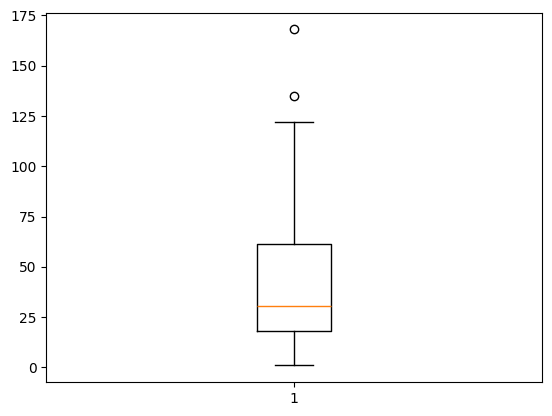

In [60]:
#Box plot
import matplotlib.pyplot as plt
data_box=data1.dropna()
data1_box=data_box.Ozone
plt.boxplot(data1_box)